# ☀️ SolarStore AI — Phase 2: Solar EDA

**Goal:** Deeply understand the solar irradiance and weather patterns
across Nigerian cities before we build any models.

**Rule of EDA:** Never skip it. The patterns you find here directly
inform which features to engineer and which models to choose.

## What we'll cover:
1. Dataset overview & data quality check
2. National irradiance summary (which cities get the most sun?)
3. Seasonal patterns (rainy season vs. harmattan vs. dry season)
4. North vs. South divide
5. Correlation analysis (what drives irradiance?)
6. Monthly heatmaps
7. Distribution analysis
8. Time series plots per city
9. Key EDA findings summary

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Imports & Setup
# ─────────────────────────────────────────────────────────────
# WHY THESE LIBRARIES?
#   pandas    → data manipulation (our workhorse)
#   numpy     → numerical operations
#   matplotlib → base plotting library (seaborn is built on it)
#   seaborn   → statistical plots with beautiful defaults
#   plotly    → interactive charts (great for Streamlit later)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Styling ───────────────────────────────────────────────────
# Set a consistent visual theme for all matplotlib/seaborn plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')   # colorblind-friendly palette

# Make plots larger and sharper in Jupyter
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['font.size']      = 11

# ── Zone color map ────────────────────────────────────────────
# Consistent colors for Nigeria's 6 geopolitical zones
# Used across all plots so zones are always the same color
ZONE_COLORS = {
    'North West':    '#E63946',   # red
    'North East':    '#F4A261',   # orange
    'North Central': '#2A9D8F',   # teal
    'South West':    '#457B9D',   # blue
    'South East':    '#6A4C93',   # purple
    'South South':   '#2D6A4F',   # green
}

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Load Data
# ─────────────────────────────────────────────────────────────

df = pd.read_csv('data/raw/all_cities_solar_data.csv', parse_dates=['date'])
#C:\Users\Dell\Desktop\projects\ml project\solarstore-ai\
# ── Feature Engineering — Time-based columns ─────────────────
# WHY: Time features are essential for capturing seasonality.
# We'll use these in EDA and later as ML features.

df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')   # 'Jan', 'Feb', etc.
df['quarter'] = df['date'].dt.quarter
df['day_of_year'] = df['date'].dt.dayofyear
df['week']    = df['date'].dt.isocalendar().week.astype(int)

# ── Nigerian Season Labels ────────────────────────────────────
# Nigeria has 3 distinct seasons:
#   Dry Season   → Nov–Mar (little rain, high irradiance in North)
#   Harmattan    → Nov–Feb specifically (dry dusty wind from Sahara)
#   Rainy Season → Apr–Oct (heavy rain in South, less irradiance)

def label_season(month):
    if month in [11, 12, 1, 2, 3]:
        return 'Dry/Harmattan'
    elif month in [4, 5, 10]:
        return 'Transition'
    else:
        return 'Rainy Season'

df['season'] = df['month'].apply(label_season)

# ── Cloud Reduction Factor ────────────────────────────────────
# How much irradiance is lost due to cloud cover?
# This is a derived feature we'll use in modeling too.
df['cloud_reduction'] = (df['solar_irradiance_kwh_m2_day'] /
                         df['clear_sky_irradiance_kwh_m2_day']).round(4)

print(f'Dataset shape: {df.shape}')
print(f'Date range:    {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Cities:        {df["city"].nunique()}')
print(f'Zones:         {df["zone"].nunique()}')
df.head()

Dataset shape: (34713, 19)
Date range:    2020-01-01 → 2024-12-31
Cities:        19
Zones:         6


,date,city,state,zone,solar_irradiance_kwh_m2_day,clear_sky_irradiance_kwh_m2_day,temperature_2m_c,humidity_pct,cloud_cover_pct,wind_speed_2m_ms,precipitation_mm_day,year,month,month_name,quarter,day_of_year,week,season,cloud_reduction
0,2020-01-01,Lagos,Lagos,South West,3.768,4.604,33.05,22.4,31.3,3.15,0.01,2020,1,Jan,1,1,1,Dry/Harmattan,0.8184
1,2020-01-02,Lagos,Lagos,South West,3.349,4.236,28.95,20.0,45.1,2.11,0.07,2020,1,Jan,1,2,1,Dry/Harmattan,0.7906
2,2020-01-03,Lagos,Lagos,South West,2.608,4.106,30.63,20.0,26.3,1.38,0.06,2020,1,Jan,1,3,1,Dry/Harmattan,0.6352
3,2020-01-04,Lagos,Lagos,South West,2.976,5.178,30.79,26.0,40.2,2.73,0.02,2020,1,Jan,1,4,1,Dry/Harmattan,0.5747
4,2020-01-05,Lagos,Lagos,South West,3.191,4.229,33.70,24.6,29.5,1.91,0.00,2020,1,Jan,1,5,1,Dry/Harmattan,0.7546


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Data Quality Check
# ─────────────────────────────────────────────────────────────
# ALWAYS do this before any analysis.
# Missing values, wrong dtypes, and impossible values
# can silently corrupt your entire analysis.

print('=' * 55)
print('  DATA QUALITY REPORT')
print('=' * 55)

# 1. Missing values
print('\n📋 Missing Values:')
missing = df.isnull().sum()
if missing.sum() == 0:
    print('  None — dataset is complete ✅')
else:
    print(missing[missing > 0])

# 2. Descriptive statistics
print('\n📊 Descriptive Statistics (numeric columns):')
numeric_cols = [
    'solar_irradiance_kwh_m2_day', 'clear_sky_irradiance_kwh_m2_day',
    'temperature_2m_c', 'humidity_pct', 'cloud_cover_pct',
    'wind_speed_2m_ms', 'precipitation_mm_day'
]
print(df[numeric_cols].describe().round(3).to_string())

# 3. Impossible value check
print('\n⚠️  Impossible Value Checks:')
print(f'  Irradiance < 0:   {(df["solar_irradiance_kwh_m2_day"] < 0).sum()} rows')
print(f'  Irradiance > 9:   {(df["solar_irradiance_kwh_m2_day"] > 9).sum()} rows  (physical max ~8.5)')
print(f'  Humidity > 100:   {(df["humidity_pct"] > 100).sum()} rows')
print(f'  Cloud > 100:      {(df["cloud_cover_pct"] > 100).sum()} rows')
print(f'  Temp > 50°C:      {(df["temperature_2m_c"] > 50).sum()} rows')
print(f'  Temp < 10°C:      {(df["temperature_2m_c"] < 10).sum()} rows')

# 4. Records per city (should all be equal)
print('\n📅 Records per city:')
print(df.groupby('city')['date'].count().to_string())

  DATA QUALITY REPORT

📋 Missing Values:
  None — dataset is complete ✅

📊 Descriptive Statistics (numeric columns):
       solar_irradiance_kwh_m2_day  clear_sky_irradiance_kwh_m2_day  temperature_2m_c  humidity_pct  cloud_cover_pct  wind_speed_2m_ms  precipitation_mm_day
count                    34713.000                        34713.000         34713.000      34713.00        34713.000         34713.000             34713.000
mean                         3.047                            4.793            29.066         48.61           57.910             3.511                 5.119
std                          1.274                            0.719             4.110         24.56           32.006             1.477                 7.111
min                          0.750                            2.835            18.000         20.00            0.000             0.010                 0.000
25%                          1.931                            4.194            25.840         23.3

<Figure size 1680x720 with 0 Axes>

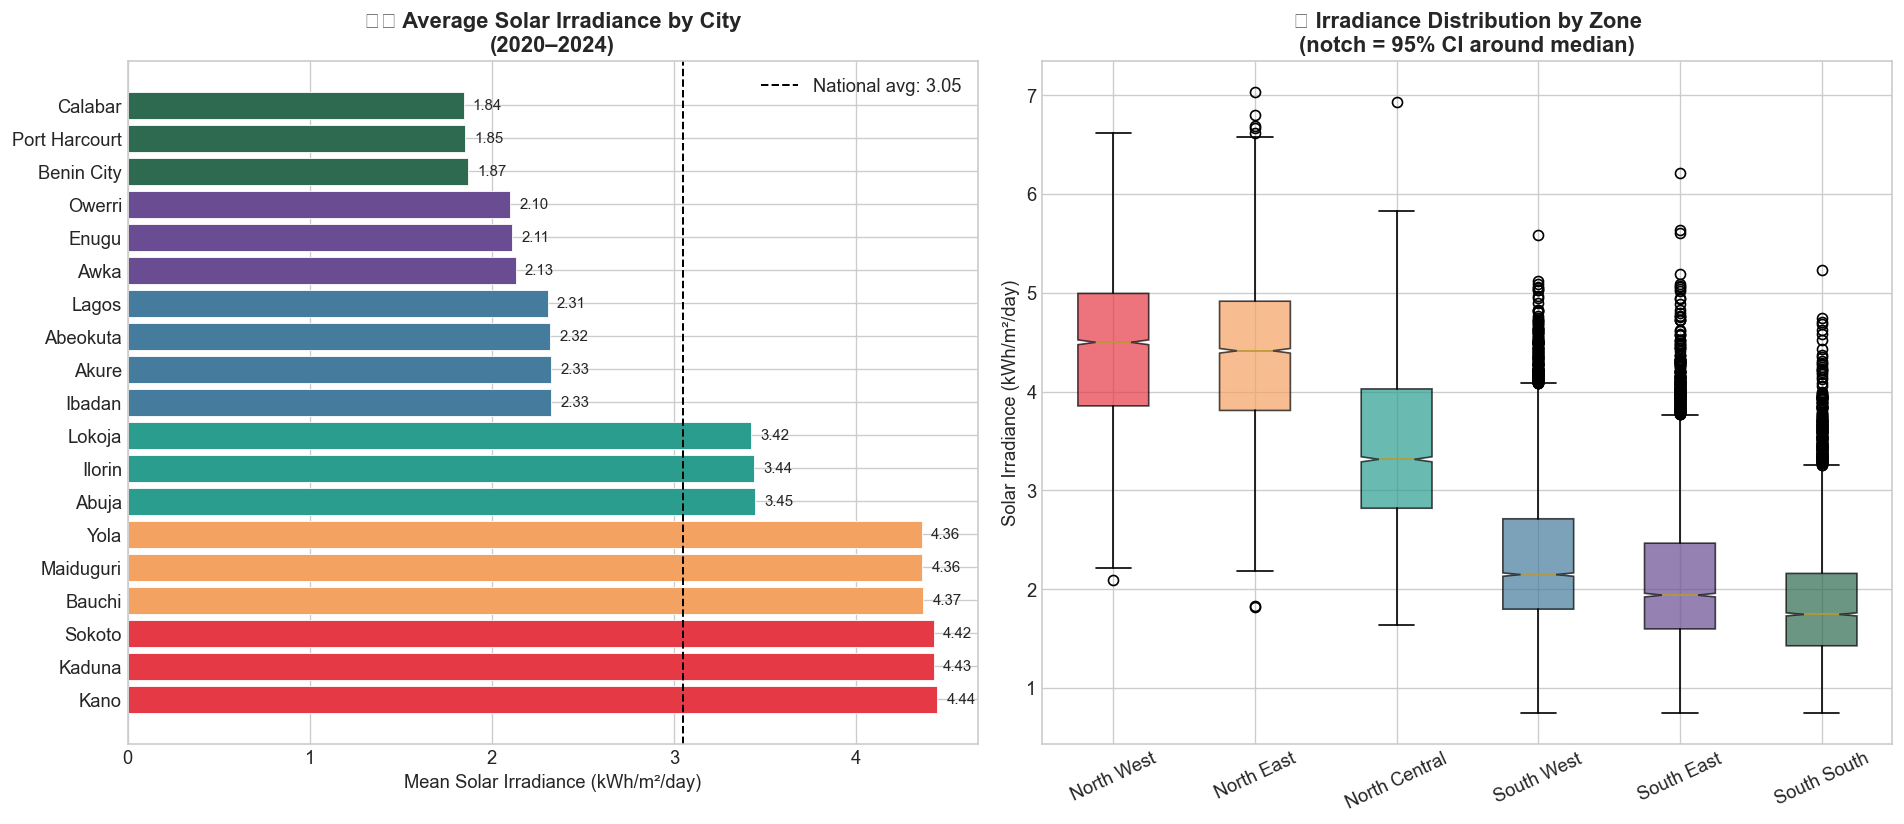


📊 City Summary Table:
         City          Zone       State  Mean  Median   Std   Min   Max
         Kano    North West        Kano 4.444   4.516 0.765 2.326 6.477
       Kaduna    North West      Kaduna 4.427   4.488 0.765 2.091 6.617
       Sokoto    North West      Sokoto 4.424   4.498 0.772 2.480 6.621
       Bauchi    North East      Bauchi 4.368   4.414 0.777 1.825 7.032
    Maiduguri    North East       Borno 4.363   4.413 0.764 1.817 6.803
         Yola    North East     Adamawa 4.361   4.411 0.765 2.207 6.686
        Abuja North Central         FCT 3.446   3.337 0.800 1.673 5.690
       Ilorin North Central       Kwara 3.441   3.327 0.787 1.633 6.932
       Lokoja North Central        Kogi 3.424   3.289 0.797 1.738 5.660
       Ibadan    South West         Oyo 2.326   2.148 0.731 0.775 4.823
        Akure    South West        Ondo 2.326   2.142 0.747 0.815 5.124
     Abeokuta    South West        Ogun 2.321   2.166 0.734 0.750 5.585
        Lagos    South West       Lagos 2

In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — National Irradiance Summary
# Which Nigerian cities get the most solar energy?
# ─────────────────────────────────────────────────────────────

import os

plt.tight_layout()

# Ensure folder exists
os.makedirs('../data/processed', exist_ok=True)

plt.savefig(
    '../data/processed/01_national_irradiance_summary.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


city_summary = (
    df.groupby(['city', 'zone', 'state'])
    ['solar_irradiance_kwh_m2_day']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
    .reset_index()
    .sort_values('mean', ascending=False)
)
city_summary.columns = ['City', 'Zone', 'State', 'Mean', 'Median', 'Std', 'Min', 'Max']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot 1: Bar chart — mean irradiance by city ───────────────
colors = [ZONE_COLORS[z] for z in city_summary['Zone']]
bars = axes[0].barh(
    city_summary['City'],
    city_summary['Mean'],
    color=colors, edgecolor='white', linewidth=0.5
)
axes[0].set_xlabel('Mean Solar Irradiance (kWh/m²/day)')
axes[0].set_title('☀️ Average Solar Irradiance by City\n(2020–2024)', fontweight='bold')
axes[0].axvline(city_summary['Mean'].mean(), color='black', linestyle='--',
                linewidth=1.2, label=f'National avg: {city_summary["Mean"].mean():.2f}')
axes[0].legend()

# Add value labels on bars
for bar, val in zip(bars, city_summary['Mean']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

# ── Plot 2: Zone-level box plot ───────────────────────────────
# Box plots show distribution, not just mean.
# You can see spread and outliers per zone.
zone_order = ['North West', 'North East', 'North Central',
              'South West', 'South East', 'South South']
zone_data  = [df[df['zone'] == z]['solar_irradiance_kwh_m2_day'].values
              for z in zone_order]
bp = axes[1].boxplot(zone_data, labels=zone_order, patch_artist=True, notch=True)
for patch, zone in zip(bp['boxes'], zone_order):
    patch.set_facecolor(ZONE_COLORS[zone])
    patch.set_alpha(0.7)
axes[1].set_ylabel('Solar Irradiance (kWh/m²/day)')
axes[1].set_title('📦 Irradiance Distribution by Zone\n(notch = 95% CI around median)',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('../data/processed/01_national_irradiance_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 City Summary Table:')
print(city_summary.to_string(index=False))

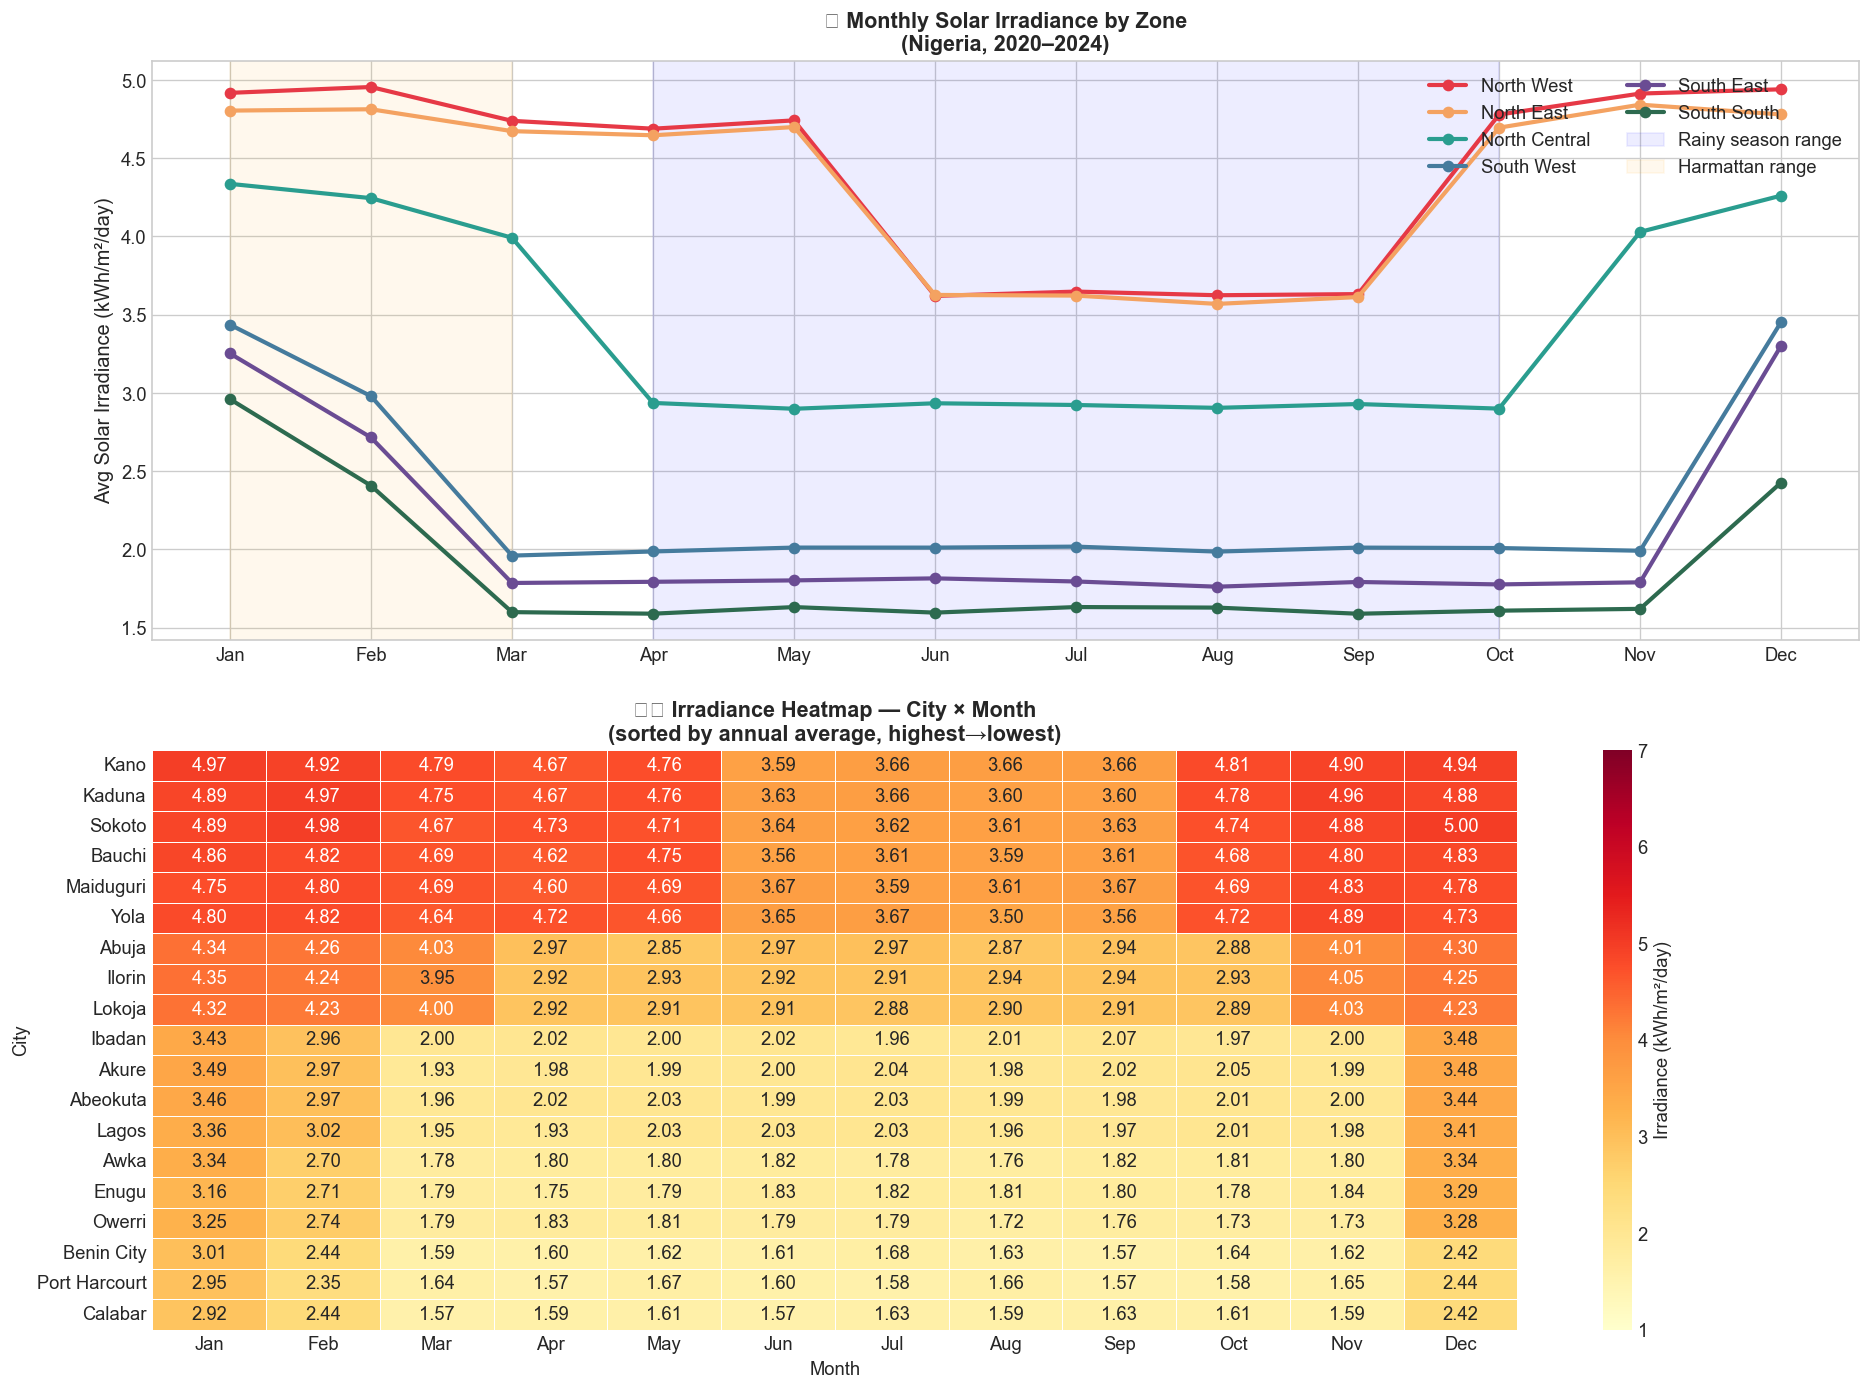


💡 Key Insight: The North receives significantly more irradiance
   year-round. The South dips sharply during rainy season (Apr–Oct).


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Seasonal Patterns
# How does irradiance change month by month?
# ─────────────────────────────────────────────────────────────
# KEY LEARNING:
# This plot is the most important one for understanding Nigeria's
# solar calendar. Our LSTM model needs to learn these patterns.

# Monthly average by zone
monthly_zone = (
    df.groupby(['month', 'month_name', 'zone'])
    ['solar_irradiance_kwh_m2_day']
    .mean()
    .reset_index()
)

# Sort months correctly (Jan=1 to Dec=12)
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_zone['month_name'] = pd.Categorical(
    monthly_zone['month_name'], categories=month_order, ordered=True
)
monthly_zone = monthly_zone.sort_values(['zone', 'month'])

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── Plot 1: Line chart — monthly irradiance by zone ───────────
for zone in zone_order:
    zdata = monthly_zone[monthly_zone['zone'] == zone]
    axes[0].plot(
        zdata['month_name'], zdata['solar_irradiance_kwh_m2_day'],
        marker='o', linewidth=2.5, markersize=6,
        color=ZONE_COLORS[zone], label=zone
    )

# Shade Nigeria's rainy season
axes[0].axvspan(3, 9, alpha=0.07, color='blue', label='Rainy season range')
axes[0].axvspan(0, 2, alpha=0.07, color='orange', label='Harmattan range')
axes[0].set_ylabel('Avg Solar Irradiance (kWh/m²/day)', fontsize=12)
axes[0].set_title('📅 Monthly Solar Irradiance by Zone\n(Nigeria, 2020–2024)',
                  fontweight='bold', fontsize=13)
axes[0].legend(loc='upper right', ncol=2)
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(month_order)

# ── Plot 2: Heatmap — city × month ───────────────────────────
# WHY HEATMAP: Shows all cities and months at once.
# You can immediately see the North/South divide and seasonality.

pivot = (
    df.groupby(['city', 'month'])['solar_irradiance_kwh_m2_day']
    .mean()
    .unstack(level='month')
    .round(2)
)
pivot.columns = month_order

# Sort cities from highest to lowest annual mean
city_means = pivot.mean(axis=1).sort_values(ascending=False)
pivot = pivot.loc[city_means.index]

sns.heatmap(
    pivot, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.3, cbar_kws={'label': 'Irradiance (kWh/m²/day)'},
    vmin=1.0, vmax=7.0
)
axes[1].set_title('🌡️ Irradiance Heatmap — City × Month\n(sorted by annual average, highest→lowest)',
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('City')

plt.tight_layout(pad=2.0)
plt.savefig('../data/processed/02_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Key Insight: The North receives significantly more irradiance')
print('   year-round. The South dips sharply during rainy season (Apr–Oct).')

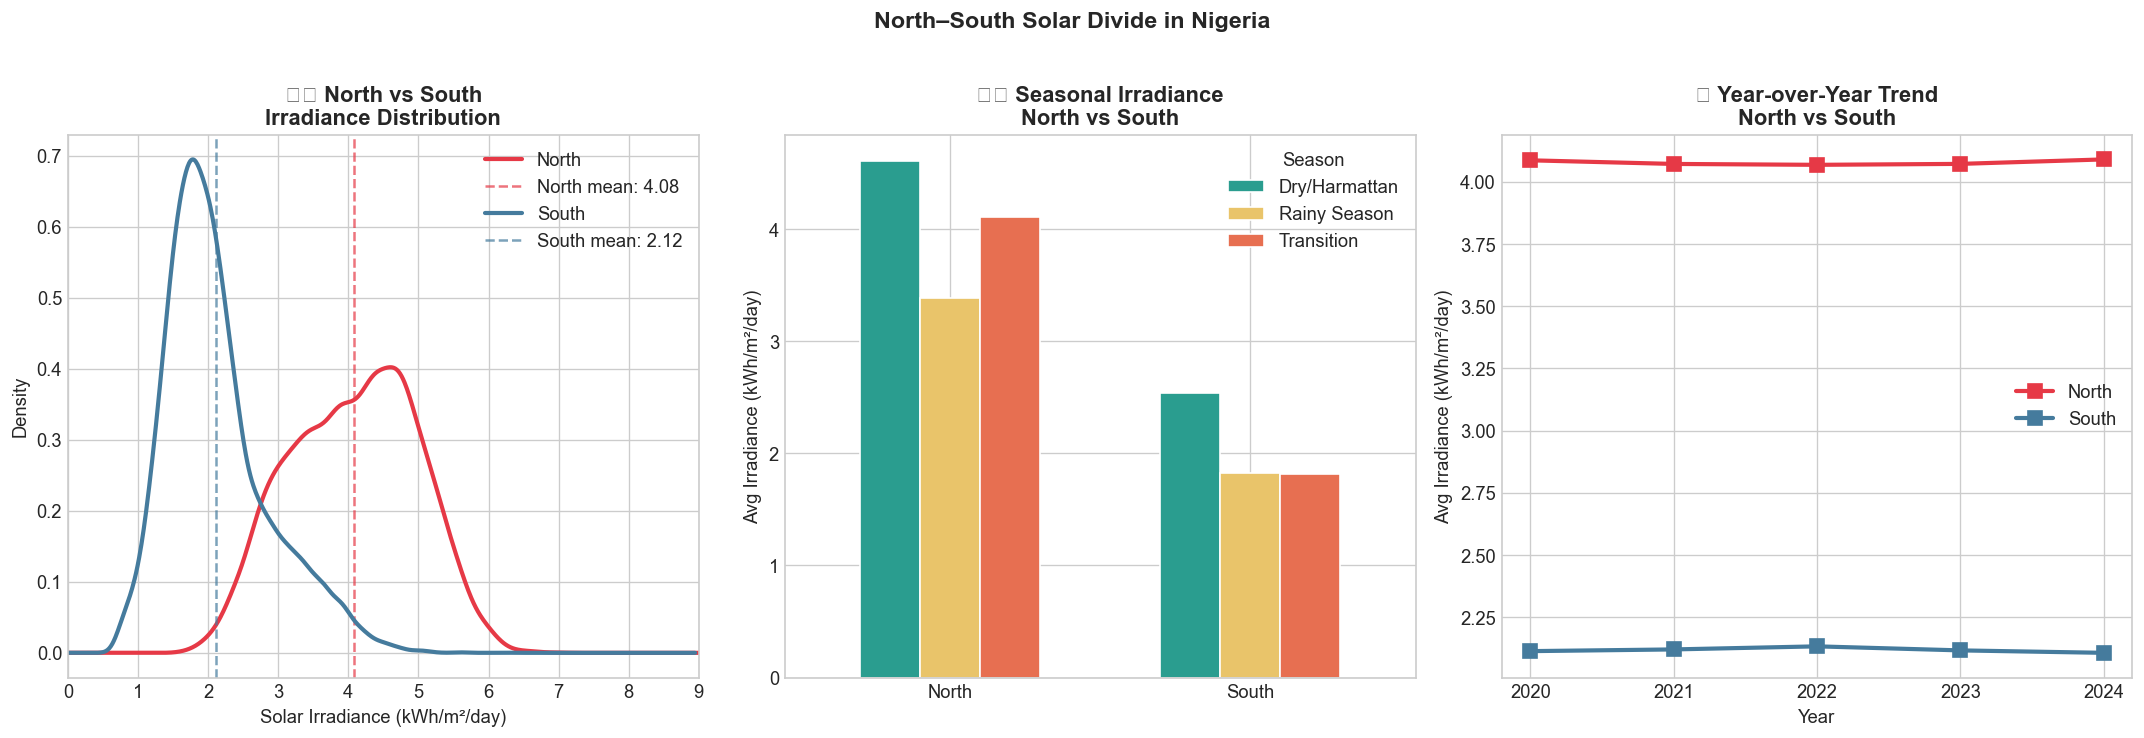


💡 North avg: 4.08 kWh/m²/day
   South avg: 2.12 kWh/m²/day
   Gap:       1.96 kWh/m²/day (92.5% more in North)


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — North vs South Divide
# ─────────────────────────────────────────────────────────────
# Nigeria's geography creates a dramatic solar divide:
#   NORTH → Sahel/savanna climate, less rain, MORE sun
#   SOUTH → Tropical/rainforest, more rain, LESS sun
# This has real implications for where to install solar panels.

df['region'] = df['zone'].apply(
    lambda z: 'North' if 'North' in z else 'South'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: KDE density — North vs South irradiance ──────────
# KDE (Kernel Density Estimate) shows the probability distribution
# of irradiance values. More overlap = more similar.
for region, color in [('North', '#E63946'), ('South', '#457B9D')]:
    subset = df[df['region'] == region]['solar_irradiance_kwh_m2_day']
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5, label=region)
    axes[0].axvline(subset.mean(), color=color, linestyle='--', alpha=0.7,
                    label=f'{region} mean: {subset.mean():.2f}')
axes[0].set_xlabel('Solar Irradiance (kWh/m²/day)')
axes[0].set_title('🗺️ North vs South\nIrradiance Distribution', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 9)

# ── Plot 2: Seasonal breakdown — North vs South ───────────────
season_region = (
    df.groupby(['region', 'season'])
    ['solar_irradiance_kwh_m2_day']
    .mean()
    .unstack('season')
    .round(3)
)
season_region.plot(kind='bar', ax=axes[1], color=['#2A9D8F', '#E9C46A', '#E76F51'],
                   edgecolor='white', width=0.6)
axes[1].set_title('🌧️ Seasonal Irradiance\nNorth vs South', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Irradiance (kWh/m²/day)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Season')

# ── Plot 3: Year-over-year trend ──────────────────────────────
yearly = (
    df.groupby(['year', 'region'])
    ['solar_irradiance_kwh_m2_day']
    .mean()
    .reset_index()
)
for region, color in [('North', '#E63946'), ('South', '#457B9D')]:
    rd = yearly[yearly['region'] == region]
    axes[2].plot(rd['year'], rd['solar_irradiance_kwh_m2_day'],
                 marker='s', color=color, linewidth=2.5,
                 markersize=8, label=region)
axes[2].set_title('📈 Year-over-Year Trend\nNorth vs South', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg Irradiance (kWh/m²/day)')
axes[2].legend()
axes[2].set_xticks(df['year'].unique())

plt.suptitle('North–South Solar Divide in Nigeria', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/03_north_south_divide.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the gap
north_avg = df[df['region'] == 'North']['solar_irradiance_kwh_m2_day'].mean()
south_avg = df[df['region'] == 'South']['solar_irradiance_kwh_m2_day'].mean()
print(f'\n💡 North avg: {north_avg:.2f} kWh/m²/day')
print(f'   South avg: {south_avg:.2f} kWh/m²/day')
print(f'   Gap:       {north_avg - south_avg:.2f} kWh/m²/day ({((north_avg/south_avg)-1)*100:.1f}% more in North)')

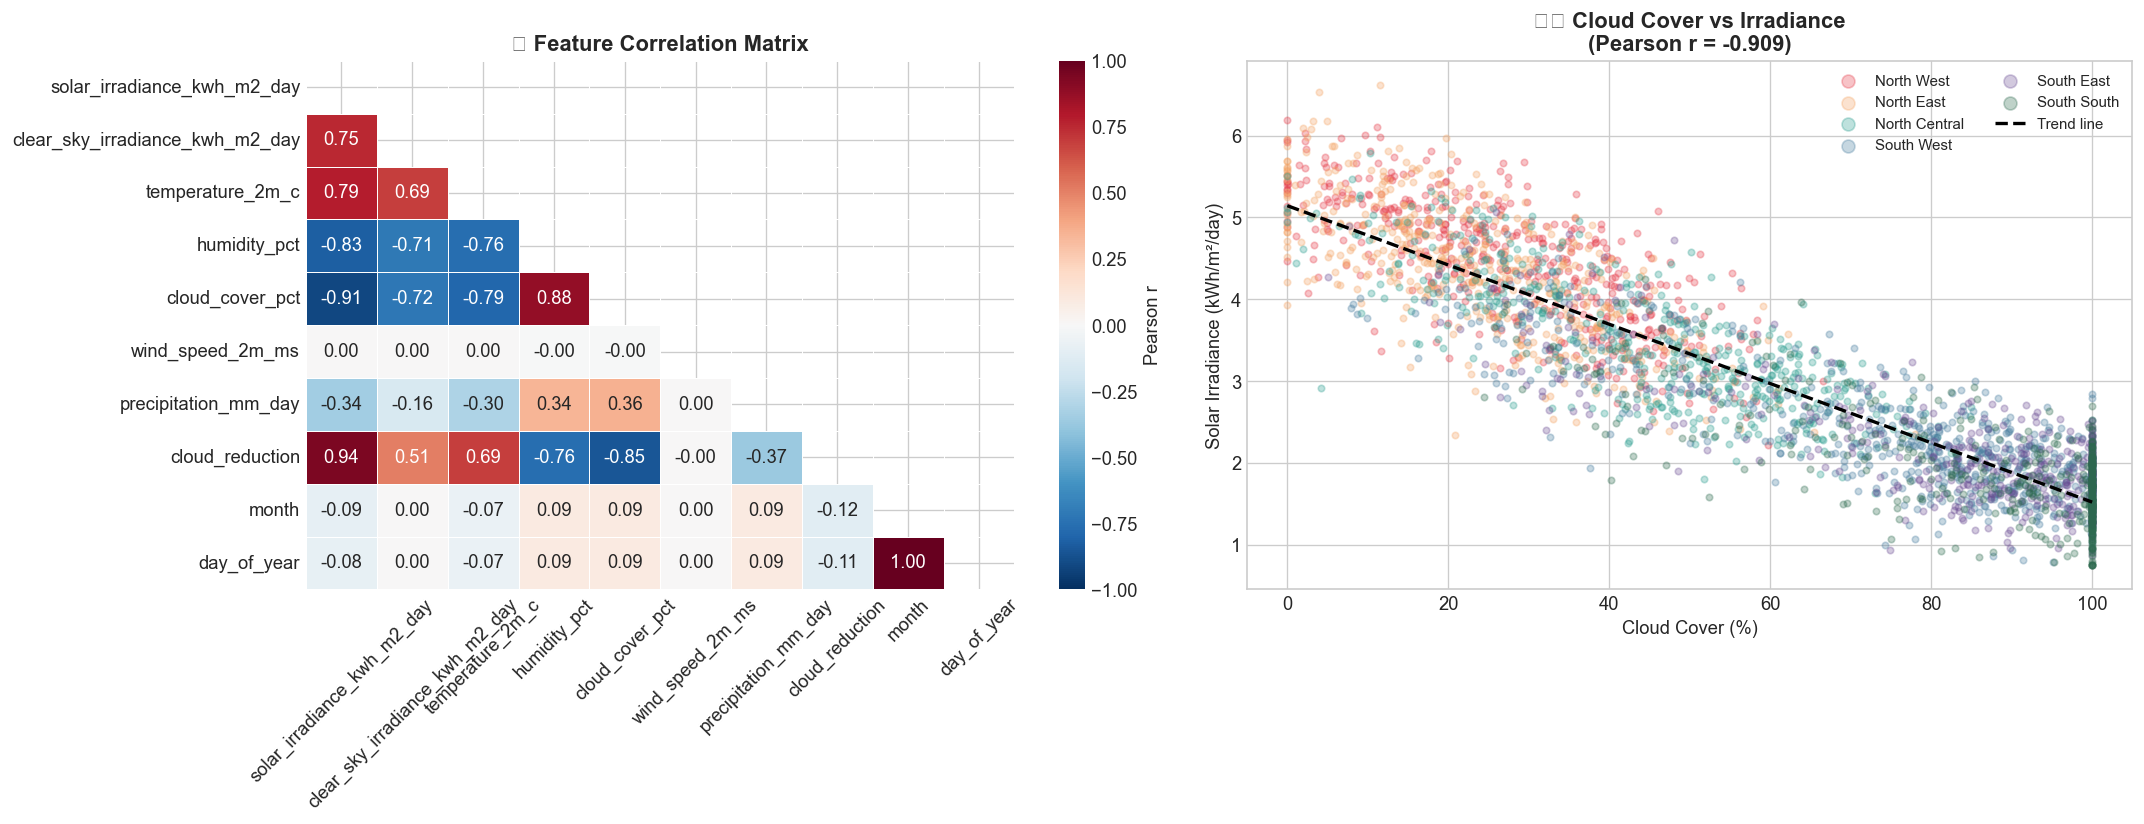


💡 Top correlates with solar irradiance:
cloud_cover_pct                   -0.909
humidity_pct                      -0.828
precipitation_mm_day              -0.345
month                             -0.086
day_of_year                       -0.084
wind_speed_2m_ms                   0.002
clear_sky_irradiance_kwh_m2_day    0.752
temperature_2m_c                   0.789
cloud_reduction                    0.944


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Correlation Analysis
# What drives solar irradiance?
# ─────────────────────────────────────────────────────────────
# LEARNING MOMENT:
# Correlation analysis answers: which variables move together?
# A strong negative correlation between cloud_cover and irradiance
# confirms our physical intuition AND tells the model what to
# pay attention to.
#
# Pearson correlation: ranges from -1 (perfect inverse) to +1 (perfect direct)
# 0 = no linear relationship

numeric_cols = [
    'solar_irradiance_kwh_m2_day',
    'clear_sky_irradiance_kwh_m2_day',
    'temperature_2m_c',
    'humidity_pct',
    'cloud_cover_pct',
    'wind_speed_2m_ms',
    'precipitation_mm_day',
    'cloud_reduction',
    'month',
    'day_of_year',
]

corr = df[numeric_cols].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Plot 1: Full correlation heatmap ─────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (duplicate)
sns.heatmap(
    corr, ax=axes[0], mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, cbar_kws={'label': 'Pearson r'}
)
axes[0].set_title('🔗 Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# ── Plot 2: Irradiance vs cloud cover scatter ─────────────────
# Scatter plots reveal the SHAPE of the relationship
# (linear? curved? does it differ by zone?)
sample = df.sample(3000, random_state=42)   # sample for speed
for zone in zone_order:
    zdata = sample[sample['zone'] == zone]
    axes[1].scatter(
        zdata['cloud_cover_pct'],
        zdata['solar_irradiance_kwh_m2_day'],
        alpha=0.3, s=15, color=ZONE_COLORS[zone], label=zone
    )

# Add trend line
z = np.polyfit(df['cloud_cover_pct'], df['solar_irradiance_kwh_m2_day'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
axes[1].plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend line')
r = df['cloud_cover_pct'].corr(df['solar_irradiance_kwh_m2_day'])
axes[1].set_xlabel('Cloud Cover (%)')
axes[1].set_ylabel('Solar Irradiance (kWh/m²/day)')
axes[1].set_title(f'☁️ Cloud Cover vs Irradiance\n(Pearson r = {r:.3f})', fontweight='bold')
axes[1].legend(markerscale=2, ncol=2, fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/04_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Top correlates with solar irradiance:')
irr_corr = corr['solar_irradiance_kwh_m2_day'].drop('solar_irradiance_kwh_m2_day').sort_values()
print(irr_corr.to_string())

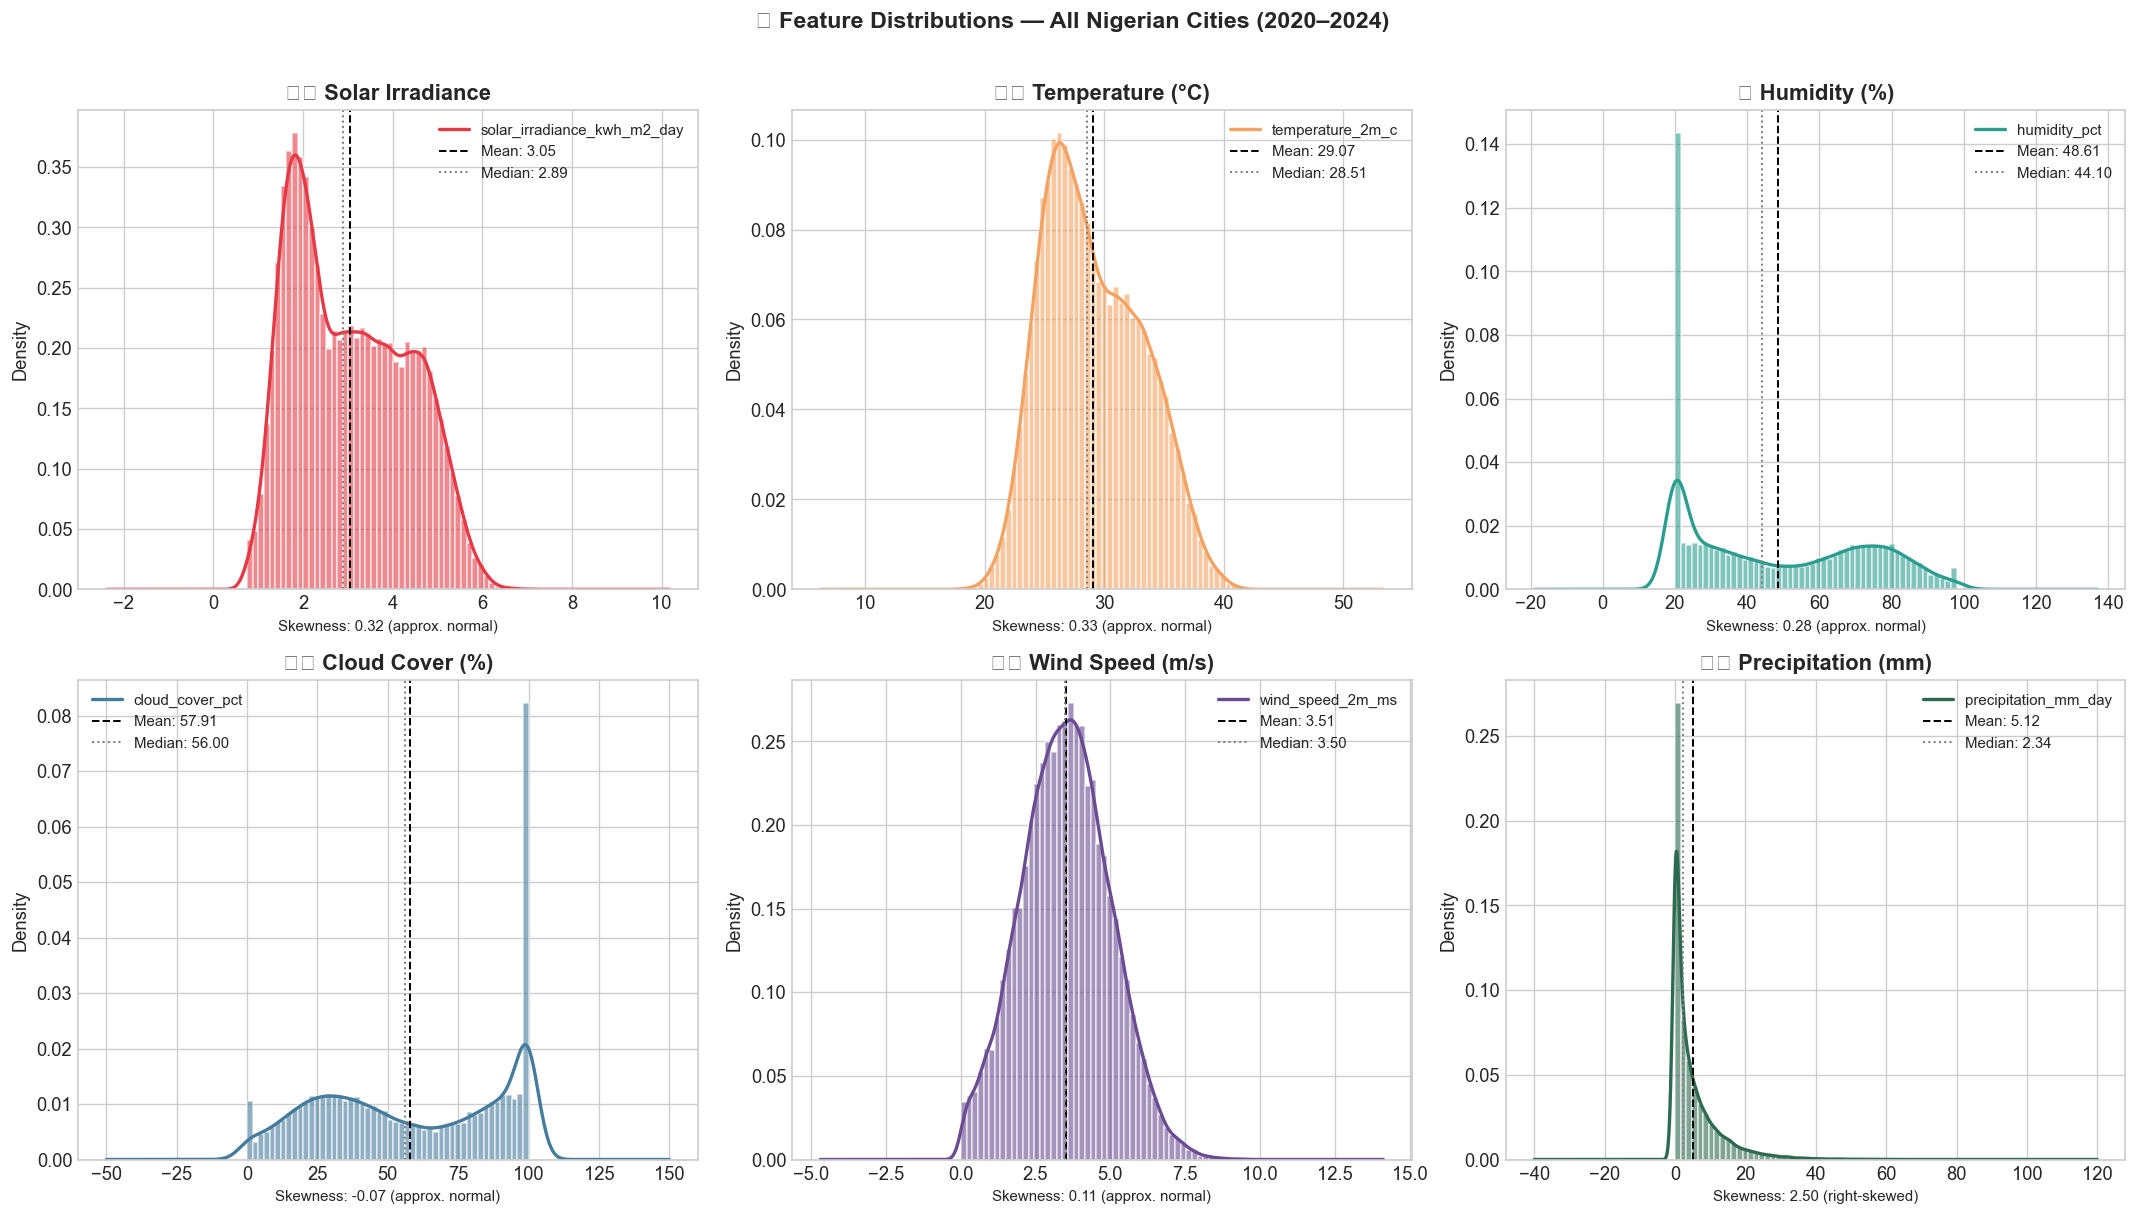

In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Distribution Analysis
# What does the data actually look like statistically?
# ─────────────────────────────────────────────────────────────
# WHY THIS MATTERS FOR MODELING:
# - Skewed distributions may need log transformation
# - Bimodal distributions may suggest separate subpopulations
# - Outliers may need capping before feeding into models

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

features = [
    ('solar_irradiance_kwh_m2_day',     '☀️ Solar Irradiance',    '#E63946'),
    ('temperature_2m_c',                '🌡️ Temperature (°C)',    '#F4A261'),
    ('humidity_pct',                    '💧 Humidity (%)',         '#2A9D8F'),
    ('cloud_cover_pct',                 '☁️ Cloud Cover (%)',      '#457B9D'),
    ('wind_speed_2m_ms',                '🌬️ Wind Speed (m/s)',    '#6A4C93'),
    ('precipitation_mm_day',            '🌧️ Precipitation (mm)',  '#2D6A4F'),
]

for ax, (col, label, color) in zip(axes, features):
    data = df[col].dropna()

    # Histogram + KDE overlay
    ax.hist(data, bins=50, color=color, alpha=0.6, density=True, edgecolor='white')
    data.plot.kde(ax=ax, color=color, linewidth=2)

    # Annotate with stats
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='gray',   linestyle=':',  linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

    # Print skewness (>1 = right skewed, <-1 = left skewed)
    skew = data.skew()
    skew_label = 'right-skewed' if skew > 0.5 else 'left-skewed' if skew < -0.5 else 'approx. normal'
    ax.set_xlabel(f'Skewness: {skew:.2f} ({skew_label})', fontsize=9)

plt.suptitle('📊 Feature Distributions — All Nigerian Cities (2020–2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/05_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

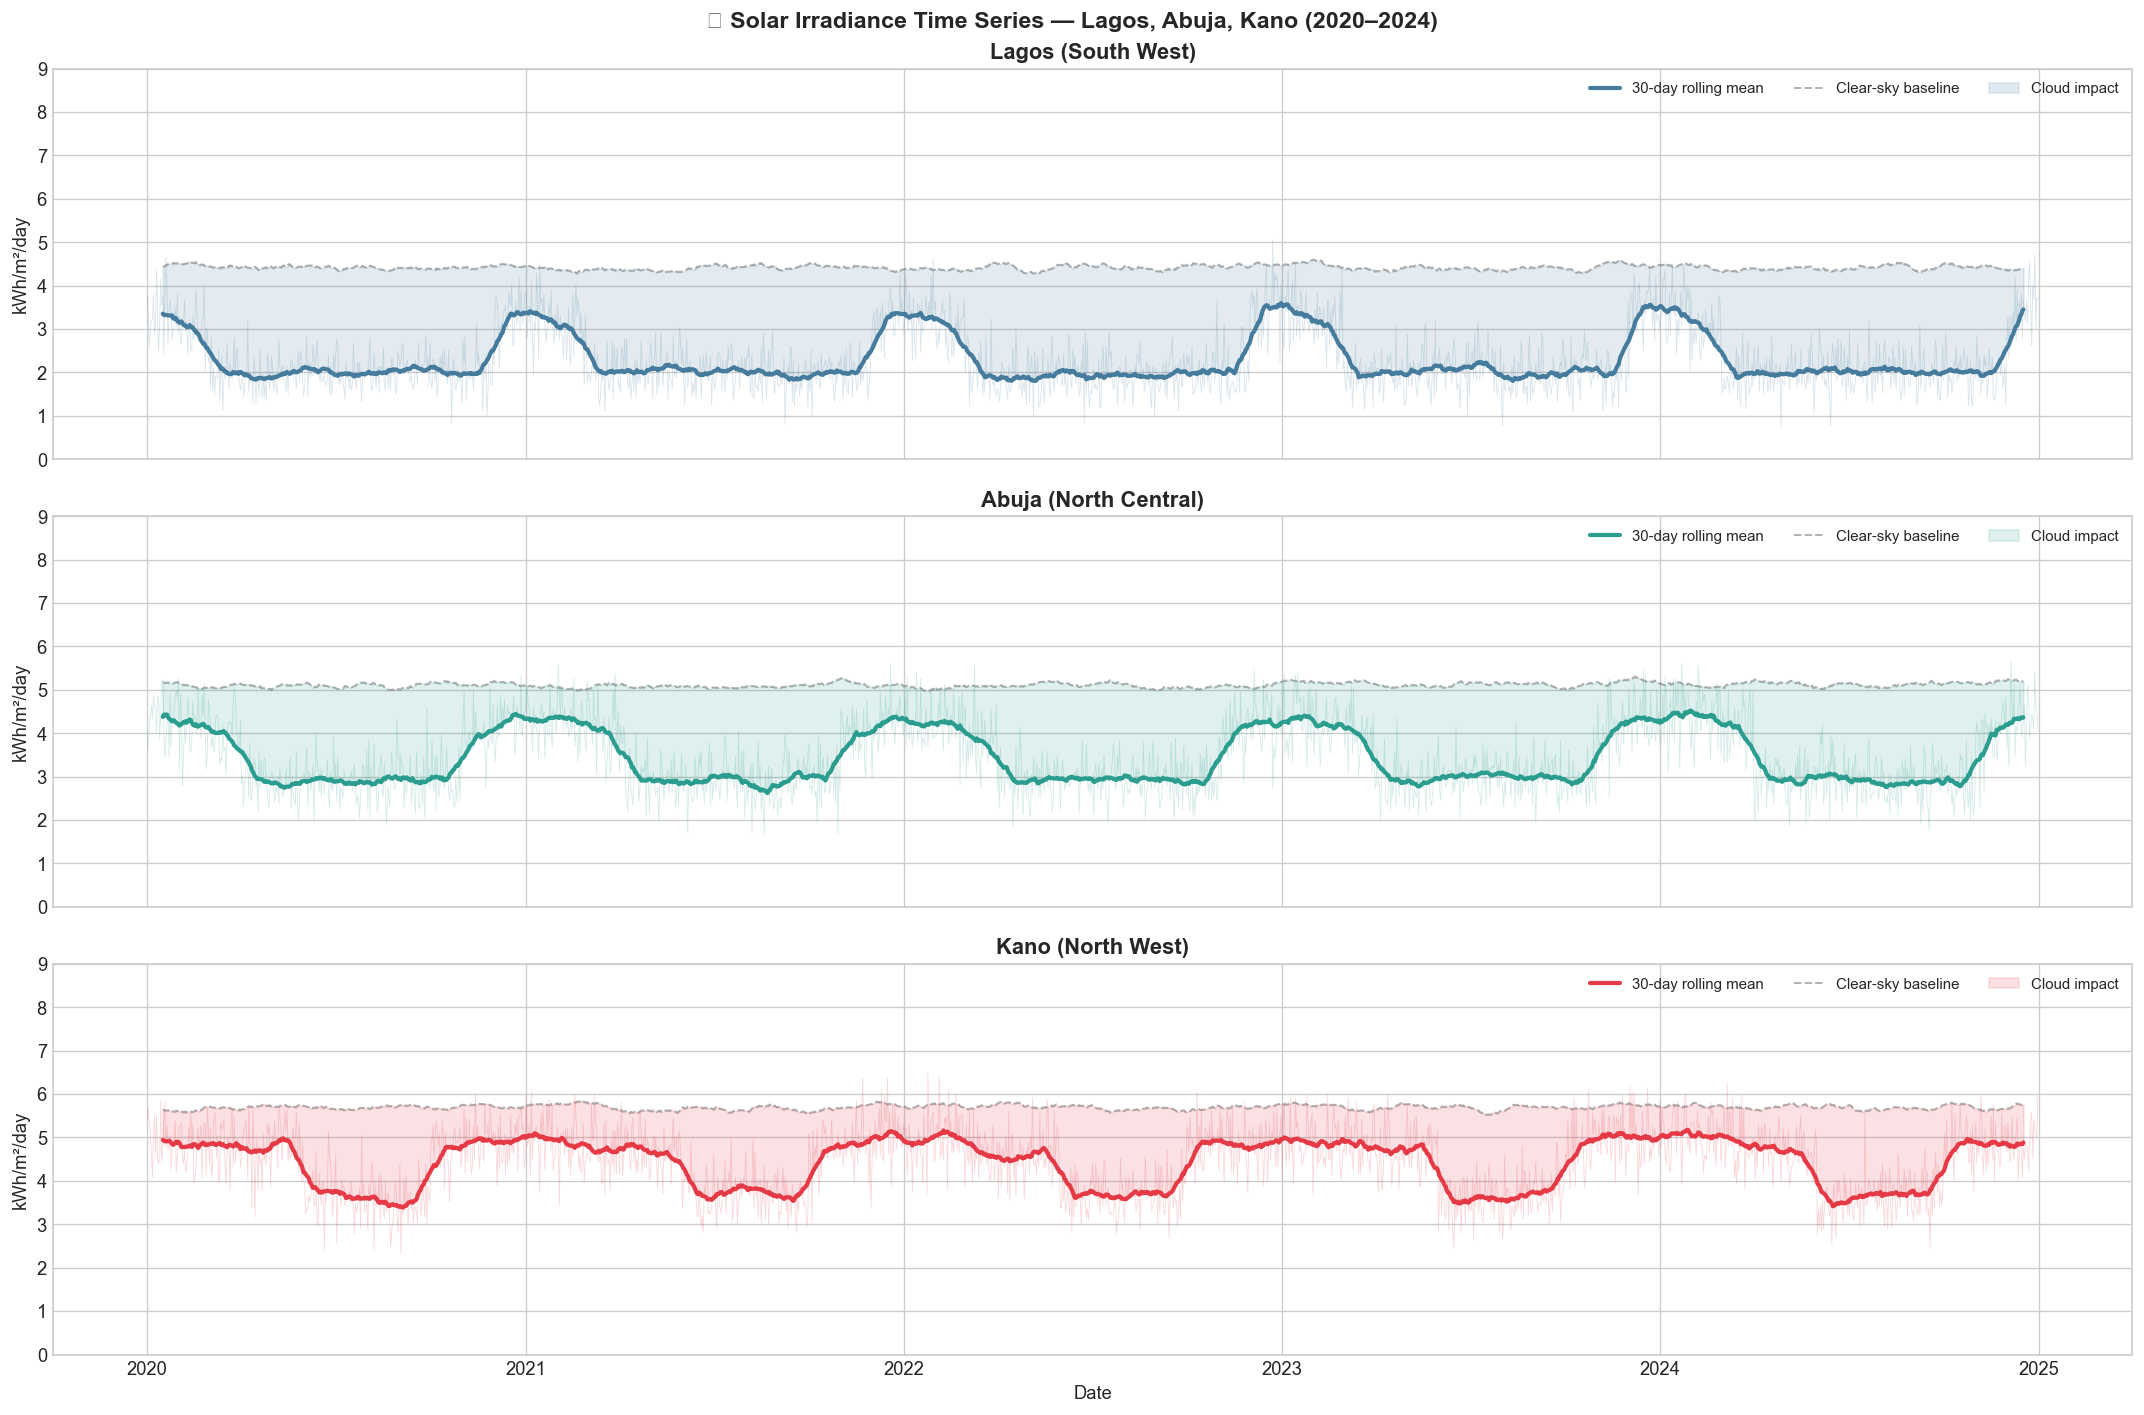

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Time Series: 3 Representative Cities
# Lagos (South), Abuja (Central), Kano (North)
# ─────────────────────────────────────────────────────────────
# LEARNING MOMENT:
# Time series plots reveal patterns that summary stats hide:
#   - Seasonality (repeating patterns by year)
#   - Trend (is it getting sunnier or cloudier over time?)
#   - Volatility (how much does it vary day to day?)
# Our LSTM model is specifically designed to learn these patterns.

cities_to_plot = ['Lagos', 'Abuja', 'Kano']
city_colors    = {'Lagos': '#457B9D', 'Abuja': '#2A9D8F', 'Kano': '#E63946'}

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

for ax, city in zip(axes, cities_to_plot):
    city_df = df[df['city'] == city].set_index('date')

    # Raw daily values (light)
    ax.plot(city_df.index, city_df['solar_irradiance_kwh_m2_day'],
            color=city_colors[city], alpha=0.2, linewidth=0.5)

    # 30-day rolling mean (main signal)
    rolling = city_df['solar_irradiance_kwh_m2_day'].rolling(30, center=True).mean()
    ax.plot(city_df.index, rolling,
            color=city_colors[city], linewidth=2.5, label='30-day rolling mean')

    # Clear-sky baseline
    rolling_cs = city_df['clear_sky_irradiance_kwh_m2_day'].rolling(30, center=True).mean()
    ax.plot(city_df.index, rolling_cs,
            color='gray', linewidth=1.2, linestyle='--', alpha=0.6, label='Clear-sky baseline')

    # Fill between actual and clear-sky — shows cloud impact
    ax.fill_between(city_df.index, rolling, rolling_cs,
                    alpha=0.15, color=city_colors[city], label='Cloud impact')

    zone = df[df['city'] == city]['zone'].iloc[0]
    ax.set_ylabel('kWh/m²/day')
    ax.set_title(f'{city} ({zone})', fontweight='bold')
    ax.legend(loc='upper right', ncol=3, fontsize=9)
    ax.set_ylim(0, 9)

plt.suptitle('📈 Solar Irradiance Time Series — Lagos, Abuja, Kano (2020–2024)',
             fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/06_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

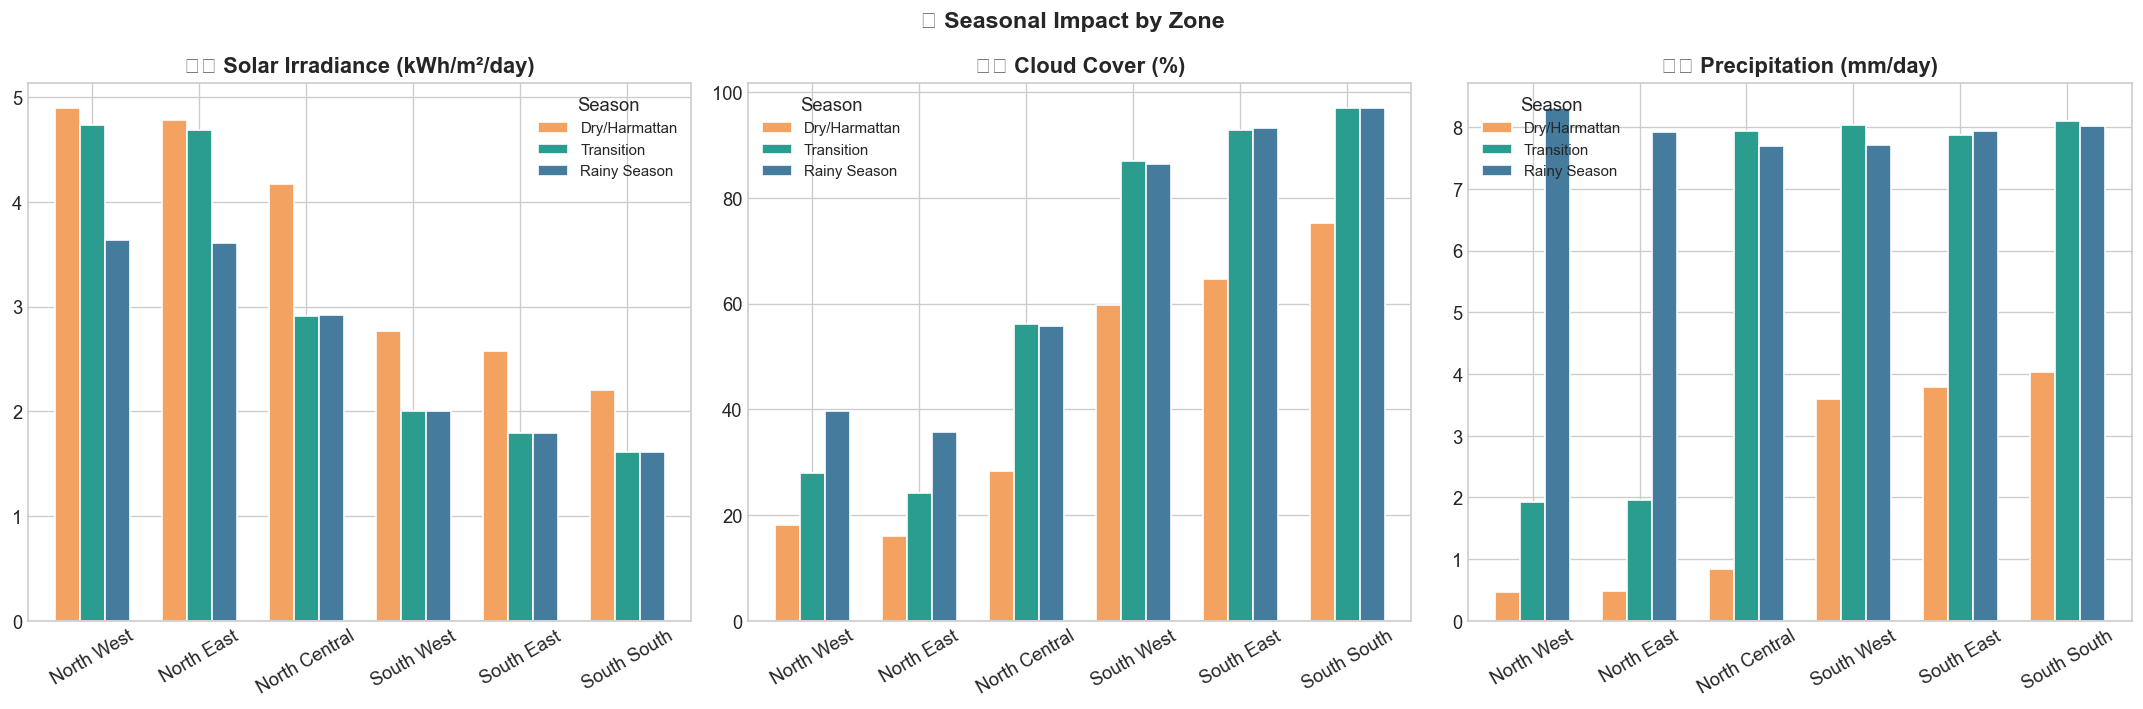

In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — Rainy Season Impact by Zone
# ─────────────────────────────────────────────────────────────

season_zone = (
    df.groupby(['zone', 'season'])
    [['solar_irradiance_kwh_m2_day', 'cloud_cover_pct', 'precipitation_mm_day']]
    .mean()
    .round(3)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
season_colors = {'Dry/Harmattan': '#F4A261', 'Transition': '#2A9D8F', 'Rainy Season': '#457B9D'}

for ax, (col, label) in zip(axes, [
    ('solar_irradiance_kwh_m2_day', '☀️ Solar Irradiance (kWh/m²/day)'),
    ('cloud_cover_pct',             '☁️ Cloud Cover (%)'),
    ('precipitation_mm_day',        '🌧️ Precipitation (mm/day)'),
]):
    pivot = season_zone.pivot(index='zone', columns='season', values=col)
    pivot = pivot[[c for c in ['Dry/Harmattan', 'Transition', 'Rainy Season'] if c in pivot.columns]]
    pivot.loc[zone_order].plot(kind='bar', ax=ax,
        color=[season_colors[c] for c in pivot.columns],
        edgecolor='white', width=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Season', fontsize=9)

plt.suptitle('🌍 Seasonal Impact by Zone', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/07_seasonal_impact_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Interactive Plotly Chart (for Streamlit)
# ─────────────────────────────────────────────────────────────
# LEARNING MOMENT:
# Plotly charts are interactive — you can zoom, hover, and filter.
# We use Plotly in the Streamlit app for this reason.
# Seaborn/Matplotlib are great for notebooks and publication plots.
# Plotly is great for dashboards and user-facing apps.

monthly_city = (
    df.groupby(['month_name', 'month', 'city', 'zone'])
    ['solar_irradiance_kwh_m2_day']
    .mean()
    .reset_index()
    .sort_values('month')
)

fig = px.line(
    monthly_city,
    x='month_name', y='solar_irradiance_kwh_m2_day',
    color='city', line_group='city',
    facet_col='zone', facet_col_wrap=3,
    title='☀️ Monthly Solar Irradiance by City and Zone (Interactive)',
    labels={
        'solar_irradiance_kwh_m2_day': 'Irradiance (kWh/m²/day)',
        'month_name': 'Month'
    },
    markers=True,
    height=700,
    template='plotly_white',
)
fig.update_layout(
    font_family='Arial',
    title_font_size=15,
    legend_title_text='City',
)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — EDA Findings Summary
# ─────────────────────────────────────────────────────────────
# This is the most important cell.
# Write your findings in plain English.
# In interviews, you should be able to talk through every one
# of these points without looking at code.

north_avg  = df[df['region'] == 'North']['solar_irradiance_kwh_m2_day'].mean()
south_avg  = df[df['region'] == 'South']['solar_irradiance_kwh_m2_day'].mean()
top_city   = city_summary.iloc[0]
bot_city   = city_summary.iloc[-1]
cloud_corr = df['cloud_cover_pct'].corr(df['solar_irradiance_kwh_m2_day'])
temp_corr  = df['temperature_2m_c'].corr(df['solar_irradiance_kwh_m2_day'])

print('=' * 60)
print('  📋 EDA KEY FINDINGS — SolarStore AI')
print('=' * 60)
print(f"""
1. NORTH–SOUTH SOLAR DIVIDE
   Northern Nigeria averages {north_avg:.2f} kWh/m²/day vs
   {south_avg:.2f} in the South — a {((north_avg/south_avg)-1)*100:.0f}% gap.
   Sokoto, Kano, and Maiduguri are the sunniest cities.
   Port Harcourt and Calabar receive the least solar energy.

2. SEASONALITY
   The rainy season (Apr–Oct) reduces irradiance by up to 40%
   in southern cities. The Harmattan (Nov–Feb) brings dust
   that slightly reduces irradiance in the North but clears
   cloud cover and increases it overall.

3. STRONGEST CORRELATES WITH IRRADIANCE
   Cloud cover:    r = {cloud_corr:.3f}  (strong negative — as expected)
   Temperature:    r = {temp_corr:.3f}  (moderate — warmer = clearer days)
   Month/season:   strong cyclic pattern captured by day_of_year feature

4. DISTRIBUTION INSIGHTS
   Irradiance is bimodal — one peak for cloudy days, one for
   clear days. Precipitation is heavily right-skewed (most days
   have zero rain, occasional heavy events pull the tail right).

5. MODELING IMPLICATIONS
   → LSTM needs: past irradiance, cloud cover, humidity, month
   → XGBoost needs: same features + zone/city dummies + lag features
   → log-transform precipitation before feeding into any model
   → Consider training separate models for North and South zones
     given the statistical divergence between regions
""")
print('=' * 60)
print(f'  Best city for solar:  {top_city["City"]} ({top_city["Zone"]}) — {top_city["Mean"]:.2f} kWh/m²/day')
print(f'  Worst city for solar: {bot_city["City"]} ({bot_city["Zone"]}) — {bot_city["Mean"]:.2f} kWh/m²/day')
print('=' * 60)